# LLM Training Pipeline — Part 4: Direct Preference Optimization (DPO)

Stage 4 of 6. Loads `sft_model.pt` and the `preference_pairs.json` dataset Part 3 built
(the same pairs the reward model was trained on) and trains a policy directly against them
with the closed-form DPO loss — no reward model, no rollouts, no value function. Produces
`dpo_model.pt`, then compares SFT vs PPO vs DPO on held-out prompts.

**How to use this notebook:**
- Read each theory section; keep `docs/llm_training_pipeline_reference.html`
  open in another tab (Section 7) for the full derivation.
- Code and tests are already implemented and verified — run cells top to
  bottom. Answer the **Question** cells yourself.

**Parts:**
1. DPO Loss
2. DPO Training Loop
3. SFT vs PPO vs DPO Comparison

In [1]:
import time, math, os, json, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tokenizers import ByteLevelBPETokenizer

import sys
sys.path.insert(0, '../..')
from src.llm_pipeline.model import GPTConfig, GPTModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

CKPT_DIR = "../../data/checkpoints/llm_training_pipeline"
torch.manual_seed(0)

tokenizer = ByteLevelBPETokenizer(
    f"{CKPT_DIR}/tinystories_bpe-vocab.json",
    f"{CKPT_DIR}/tinystories_bpe-merges.txt",
)
EOT_ID = tokenizer.token_to_id('<|endoftext|>')

sft_ckpt = torch.load(f"{CKPT_DIR}/sft_model.pt", weights_only=False)
sft_cfg = sft_ckpt['config']
sft_model = GPTModel(sft_cfg).to(device)
sft_model.load_state_dict(sft_ckpt['model_state_dict'])
sft_model.eval()
BLOCK_SIZE = sft_cfg.block_size
print(f"Loaded sft_model.pt — {sum(p.numel() for p in sft_model.parameters()):,} params")

with open(f"{CKPT_DIR}/preference_pairs.json") as f:
    preference_pairs = json.load(f)
print(f"Loaded {len(preference_pairs)} preference pairs from Part 3")

Device: cuda


Loaded sft_model.pt — 13,817,856 params
Loaded 199 preference pairs from Part 3


---
## Part 1: DPO Loss

`tokenize_prompt_response` generalizes Part 2's `tokenize_sft_example` to arbitrary prompt
and response strings (not just the SFT topic template) — the mask boundary rule is
identical: a target token is masked (`-100`) iff it falls inside the prompt or padding
region. `sequence_logprob` sums the log-probability of the response tokens only, giving
`log pi(y|x)` for a whole completion. `dpo_loss` implements the closed-form loss from
`docs/llm_training_pipeline_reference.html#s7` directly.

In [2]:
def tokenize_prompt_response(prompt, response, tokenizer, eot_id, block_size):
    prompt_ids = tokenizer.encode(prompt).ids
    completion_ids = tokenizer.encode(response).ids + [eot_id]
    full_ids = (prompt_ids + completion_ids)[: block_size + 1]
    n_prompt = min(len(prompt_ids), len(full_ids))
    n_real = len(full_ids)

    pad_len = (block_size + 1) - n_real
    full_ids = full_ids + [eot_id] * pad_len

    input_ids = full_ids[:-1]
    targets_raw = full_ids[1:]

    labels = []
    for i in range(block_size):
        target_pos = i + 1
        if target_pos < n_prompt or target_pos >= n_real:
            labels.append(-100)
        else:
            labels.append(targets_raw[i])

    return (
        torch.tensor(input_ids, dtype=torch.long),
        torch.tensor(labels, dtype=torch.long),
    )


def sequence_logprob(model, input_ids, labels):
    """Returns (B,): sum of log pi(token) over only the non-masked (response)
    positions in each sequence — log pi(y|x) for the whole completion."""
    logits, _ = model(input_ids)
    logprobs = F.log_softmax(logits, dim=-1)
    mask = labels != -100
    safe_labels = labels.clone()
    safe_labels[~mask] = 0
    token_logprobs = logprobs.gather(-1, safe_labels.unsqueeze(-1)).squeeze(-1)
    token_logprobs = token_logprobs * mask
    return token_logprobs.sum(dim=-1)


def dpo_loss(policy_chosen_lp, policy_rejected_lp, ref_chosen_lp, ref_rejected_lp, beta=0.1):
    pi_logratios = policy_chosen_lp - policy_rejected_lp
    ref_logratios = ref_chosen_lp - ref_rejected_lp
    logits = beta * (pi_logratios - ref_logratios)
    return -F.logsigmoid(logits).mean()

In [3]:
# TEST 1: DPO loss against a hand-computed toy example, plus a monotonicity sanity check
policy_chosen_lp = torch.tensor([-2.0])
policy_rejected_lp = torch.tensor([-3.0])
ref_chosen_lp = torch.tensor([-2.5])
ref_rejected_lp = torch.tensor([-2.5])
beta = 0.5

loss = dpo_loss(policy_chosen_lp, policy_rejected_lp, ref_chosen_lp, ref_rejected_lp, beta)
# by hand: pi_logratios = -2.0 - (-3.0) = 1.0; ref_logratios = -2.5 - (-2.5) = 0.0
# logits = 0.5 * (1.0 - 0.0) = 0.5; loss = -log(sigmoid(0.5)), computed independently below
expected = -math.log(1.0 / (1.0 + math.exp(-0.5)))
assert abs(loss.item() - expected) < 1e-5, f"{loss.item()} != {expected}"
print(f"TEST 1a PASSED — DPO loss matches hand-computed value ({loss.item():.4f})")

# Monotonicity: loss should be lower when the policy prefers chosen over rejected
# *more strongly relative to the reference* than in a case where it prefers the opposite.
loss_good = dpo_loss(torch.tensor([-1.0]), torch.tensor([-3.0]), torch.tensor([-2.0]), torch.tensor([-2.0]), beta=0.5)
loss_bad = dpo_loss(torch.tensor([-3.0]), torch.tensor([-1.0]), torch.tensor([-2.0]), torch.tensor([-2.0]), beta=0.5)
assert loss_good.item() < loss_bad.item(), "DPO loss should be lower when the policy prefers chosen over rejected relative to the reference"
print(f"TEST 1b PASSED — loss_good ({loss_good.item():.4f}) < loss_bad ({loss_bad.item():.4f})")

TEST 1a PASSED — DPO loss matches hand-computed value (0.4741)
TEST 1b PASSED — loss_good (0.3133) < loss_bad (1.3133)


In [4]:
# TEST 2: tokenize_prompt_response mask boundary (same rule as SFT's tokenize_sft_example)
prompt, response = "Write a short story about dog:\n", "A dog ran fast."
prompt_len = len(tokenizer.encode(prompt).ids)
input_ids, labels = tokenize_prompt_response(prompt, response, tokenizer, EOT_ID, BLOCK_SIZE)
assert input_ids.shape == (BLOCK_SIZE,) and labels.shape == (BLOCK_SIZE,)
assert torch.all(labels[: prompt_len - 1] == -100), "prompt-region targets not fully masked"
assert labels[prompt_len - 1].item() != -100, "first response token incorrectly masked"
print(f"TEST 2 PASSED — mask boundary correct (prompt_len={prompt_len})")

TEST 2 PASSED — mask boundary correct (prompt_len=10)


### Question 1

`sequence_logprob` sums log-probabilities over the response tokens rather than averaging
them. Suppose `y_w` (chosen) is a much longer response than `y_l` (rejected) for the same
prompt. Could summing (rather than averaging) systematically bias which response the DPO
loss favors, independent of which one is actually better? What would change if
`sequence_logprob` divided by the number of response tokens instead?

*Write your answer below:*

---
## Part 2: DPO Training Loop

`dpo_policy` starts as a copy of `sft_model` and is the only model updated; `ref_model` is
a frozen copy of `sft_model`, exactly the same reference used by PPO in Part 3 — same
starting point, different optimization procedure. Trains for 300 steps at `beta=0.1`.

In [5]:
dpo_policy = copy.deepcopy(sft_model).to(device)
ref_model = copy.deepcopy(sft_model).to(device)
for p in ref_model.parameters():
    p.requires_grad_(False)
ref_model.eval()

held_out_pairs = preference_pairs[-30:]
train_pairs = preference_pairs[:-30]
print(f"{len(train_pairs)} training pairs, {len(held_out_pairs)} held-out pairs")

def make_dpo_batch(pairs, batch_size):
    idx = torch.randint(0, len(pairs), (batch_size,))
    chosen = [tokenize_prompt_response(pairs[i]['prompt'], pairs[i]['chosen'], tokenizer, EOT_ID, BLOCK_SIZE) for i in idx]
    rejected = [tokenize_prompt_response(pairs[i]['prompt'], pairs[i]['rejected'], tokenizer, EOT_ID, BLOCK_SIZE) for i in idx]
    c_ids = torch.stack([c[0] for c in chosen]).to(device)
    c_labels = torch.stack([c[1] for c in chosen]).to(device)
    r_ids = torch.stack([r[0] for r in rejected]).to(device)
    r_labels = torch.stack([r[1] for r in rejected]).to(device)
    return c_ids, c_labels, r_ids, r_labels

169 training pairs, 30 held-out pairs


In [6]:
dpo_steps = 300
dpo_lr = 5e-6
dpo_batch_size = 16
beta = 0.1

opt = torch.optim.AdamW(dpo_policy.parameters(), lr=dpo_lr)
losses = []
t0 = time.time()
for step in range(dpo_steps):
    c_ids, c_labels, r_ids, r_labels = make_dpo_batch(train_pairs, dpo_batch_size)

    policy_chosen_lp = sequence_logprob(dpo_policy, c_ids, c_labels)
    policy_rejected_lp = sequence_logprob(dpo_policy, r_ids, r_labels)
    with torch.no_grad():
        ref_chosen_lp = sequence_logprob(ref_model, c_ids, c_labels)
        ref_rejected_lp = sequence_logprob(ref_model, r_ids, r_labels)

    loss = dpo_loss(policy_chosen_lp, policy_rejected_lp, ref_chosen_lp, ref_rejected_lp, beta)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(dpo_policy.parameters(), 1.0)
    opt.step()
    losses.append(loss.item())
    if step % 50 == 0 or step == dpo_steps - 1:
        print(f"step {step:4d} | loss {loss.item():.3f} | elapsed {time.time()-t0:.0f}s")
print(f"DPO training elapsed: {time.time()-t0:.1f}s")

step    0 | loss 0.693 | elapsed 2s


step   50 | loss 0.218 | elapsed 12s


step  100 | loss 0.168 | elapsed 22s


step  150 | loss 0.094 | elapsed 33s


step  200 | loss 0.055 | elapsed 43s


step  250 | loss 0.022 | elapsed 53s


step  299 | loss 0.016 | elapsed 64s
DPO training elapsed: 63.5s


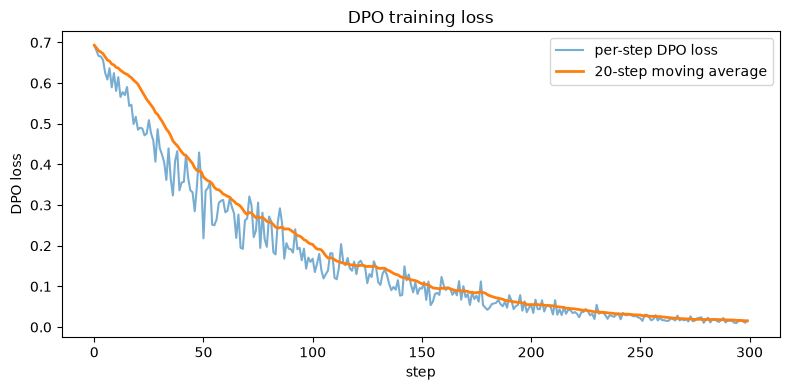

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(losses, alpha=0.6, label="per-step DPO loss")
window = 20
smoothed = [sum(losses[max(0,i-window):i+1]) / len(losses[max(0,i-window):i+1]) for i in range(len(losses))]
plt.plot(smoothed, label=f"{window}-step moving average", linewidth=2)
plt.xlabel("step"); plt.ylabel("DPO loss"); plt.title("DPO training loss")
plt.legend(); plt.tight_layout(); plt.show()

In [8]:
# TEST 3: loss decreased, and the implicit reward margin widens on held-out pairs
first_20_avg = sum(losses[:20]) / 20
last_20_avg = sum(losses[-20:]) / 20
print(f"first-20-step avg loss: {first_20_avg:.3f}, last-20-step avg loss: {last_20_avg:.3f}")
assert last_20_avg < first_20_avg, "DPO loss did not decrease over training"

@torch.no_grad()
def dpo_reward_margin(policy, ref, pairs):
    """Mean of (policy_chosen_lp - policy_rejected_lp) - (ref_chosen_lp - ref_rejected_lp)
    over a set of pairs — the implicit reward margin DPO is optimizing (Section 7)."""
    margins = []
    for p in pairs:
        c_ids, c_labels = tokenize_prompt_response(p['prompt'], p['chosen'], tokenizer, EOT_ID, BLOCK_SIZE)
        r_ids, r_labels = tokenize_prompt_response(p['prompt'], p['rejected'], tokenizer, EOT_ID, BLOCK_SIZE)
        c_ids, c_labels = c_ids.unsqueeze(0).to(device), c_labels.unsqueeze(0).to(device)
        r_ids, r_labels = r_ids.unsqueeze(0).to(device), r_labels.unsqueeze(0).to(device)
        pc = sequence_logprob(policy, c_ids, c_labels).item()
        pr = sequence_logprob(policy, r_ids, r_labels).item()
        rc = sequence_logprob(ref, c_ids, c_labels).item()
        rr = sequence_logprob(ref, r_ids, r_labels).item()
        margins.append((pc - pr) - (rc - rr))
    return sum(margins) / len(margins)

margin_before = dpo_reward_margin(sft_model, ref_model, held_out_pairs)
margin_after = dpo_reward_margin(dpo_policy, ref_model, held_out_pairs)
print(f"held-out implicit reward margin — before (sft_model): {margin_before:.3f}, after (dpo_policy): {margin_after:.3f}")
assert abs(margin_before) < 1e-3, "margin computed against the reference itself should be ~0 (sanity check)"
assert margin_after > margin_before, "DPO did not increase the implicit reward margin on held-out pairs"
print("TEST 3 PASSED — DPO loss decreased and held-out implicit reward margin increased")

first-20-step avg loss: 0.603, last-20-step avg loss: 0.015


held-out implicit reward margin — before (sft_model): 0.000, after (dpo_policy): 22.454
TEST 3 PASSED — DPO loss decreased and held-out implicit reward margin increased


### Question 2

`margin_before` is computed by comparing `sft_model` against `ref_model` — but `ref_model`
*is* a copy of `sft_model`'s weights (Part 2's setup cell). Why does `TEST 3` assert this
margin is approximately zero rather than exactly zero, and why is checking it at all a
useful sanity check on `dpo_reward_margin` itself, independent of whether DPO training
worked?

*Write your answer below:*

In [9]:
ckpt_path = f"{CKPT_DIR}/dpo_model.pt"
torch.save({'model_state_dict': dpo_policy.state_dict(), 'config': sft_cfg}, ckpt_path)
print(f"Saved DPO checkpoint to {ckpt_path}")

Saved DPO checkpoint to ../../data/checkpoints/llm_training_pipeline/dpo_model.pt
